## Frequency-domain comparison
- Update the `image_paths` mapping below with the two files you would like to compare.
- The helper code normalizes the inputs, matches their size (if `target_size` is set), and computes 2-D DCT spectra.
- Plotly heatmaps visualize the log10 magnitude of each spectrum plus their difference whenever the matrices share the same shape.
- The printed table summarizes total and high-frequency log energies so you can inspect how much energy each image carries at the selected cutoff.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.fft import dctn

In [ ]:
EPS = 1e-9

def load_image(image_path, mode="L", crop_size=None, target_size=None):
    """Load an image, convert to grayscale, optionally resize, and scale to [0, 1]."""
    path = Path(image_path).expanduser()
    if not path.exists():
        raise FileNotFoundError(f"Missing image: {path}")
    image = Image.open(path).convert(mode)
    if target_size is not None:
        image = image.resize(target_size, Image.BICUBIC)

    if crop_size is not None:
        image = image.crop((0, 0, crop_size, crop_size))
    return np.asarray(image, dtype=np.float32) / 255.0


def compute_dct_spectrum(image):
    return dctn(image, type=2, norm="ortho")

def abs_spectrum(coefficients):
    return np.abs(coefficients)

def high_frequency_mask(shape, cutoff_ratio=0.6):
    rows, cols = shape
    yy, xx = np.ogrid[:rows, :cols]
    normalized_radius = np.sqrt((yy / max(rows - 1, 1)) ** 2 + (xx / max(cols - 1, 1)) ** 2)
    return normalized_radius >= cutoff_ratio


In [16]:
# -----------------------------------------------------------------------------
# Update these paths to point at the two images you want to compare.
image_paths = {
    "Reference": "reds_000_sharp.png",
    "Low Quality": "reds_000_bicubic.png",
}
# Optional: enforce a shared spatial size before computing spectra.
target_size = None  # or set to None to preserve native sizes
high_freq_cutoff = 0.65   # normalized radius (0=DC, 1=Nyquist-like)
# -----------------------------------------------------------------------------

crop_sizes = {'Reference': 256, 'Low Quality': 64}

if len(image_paths) != 2:
    raise ValueError("Provide paths for exactly two images to compare.")

images = {name: load_image(path, target_size=target_size, crop_size=crop_sizes[name]) for name, path in image_paths.items()}
coefficients = {name: compute_dct_spectrum(image) for name, image in images.items()}
spectra = {name: coeffs for name, coeffs in coefficients.items()}

metrics = []
for name, coeffs in coefficients.items():
    magnitude = np.abs(coeffs)
    total_energy = np.square(magnitude).sum()
    mask = high_frequency_mask(magnitude.shape, cutoff_ratio=high_freq_cutoff)
    high_energy = np.square(magnitude)[mask].sum()
    metrics.append(
        {
            "image": name,
            "shape": f"{magnitude.shape[0]}x{magnitude.shape[1]}",
            "log_total_energy": np.log10(total_energy + EPS),
            "log_high_freq_energy": np.log10(high_energy + EPS),
            "high_freq_energy_ratio": high_energy / (total_energy + EPS),
        }
    )

metrics_df = pd.DataFrame(metrics).set_index("image")
display(metrics_df)

names = list(spectra.keys())

empty = np.zeros([it * 4 for it in spectra[names[1]].shape])
empty[:spectra[names[1]].shape[0], :spectra[names[1]].shape[1]] = spectra[names[1]]
spectra[names[1]] = empty
difference_available = len({spectra[name].shape for name in names}) == 1
diff_spectrum = None
if difference_available:
    diff_spectrum = spectra[names[0]] - spectra[names[1]]

n_cols = len(spectra) + (1 if diff_spectrum is not None else 0)
subplot_titles = [f"{name} log10|DCT|" for name in names]
if diff_spectrum is not None:
    subplot_titles.append("Difference (Image 1 - Image 2)")

fig = make_subplots(rows=1, cols=n_cols, subplot_titles=subplot_titles)
col_idx = 1
for name, spectrum in spectra.items():
    # compute shared colorbar limits across all spectra so each subplot uses the same range
    vmin = min(np.asarray(s).min() for s in spectra.values())
    vmax = max(np.asarray(s).max() for s in spectra.values())
    fig.add_trace(
        go.Heatmap(
            z=spectrum,
            colorscale="RdBu",
            zmin=-1.0,
            zmax=1.0,
            colorbar=dict(title="log10|DCT|"),
            showscale=False,
        ),
        row=1,
        col=col_idx,
    )
    # enforce 1:1 x-y aspect ratio for this subplot
    fig.update_yaxes(scaleanchor=f"x{col_idx}", scaleratio=1, row=1, col=col_idx)
    col_idx += 1

if diff_spectrum is not None:
    fig.add_trace(
        go.Heatmap(
            z=diff_spectrum,
            colorscale="RdBu",
            zmid=0.0,
            zmin=-1.0,
            zmax=1.0,
            colorbar=dict(title="Δ log10|DCT|"),
        ),
        row=1,
        col=col_idx,
    )
    fig.update_xaxes(title_text="Frequency X", row=1, col=col_idx)
    fig.update_yaxes(title_text="Frequency Y", row=1, col=col_idx)
    # enforce 1:1 x-y aspect ratio for the difference subplot
    fig.update_yaxes(scaleanchor=f"x{col_idx}", scaleratio=1, row=1, col=col_idx)

fig.update_layout(
    height=550,
    width=450 * n_cols,
    title_text="2-D DCT log-magnitude comparison",
    showlegend=False,
)
fig.show()

if not difference_available:
    print("Spectra have incompatible shapes; set 'target_size' to a shared value to enable the difference view.")


,shape,log_total_energy,log_high_freq_energy,high_freq_energy_ratio
image,,,,
Reference,256x256,4.572236,0.747834,0.00015
Low Quality,64x64,3.366982,0.326025,0.00091


In [ ]:
# Gaussian low-pass filter (1/N normalized radius) applied in DCT domain,
# then visualize Reference vs LPF'd image DCT magnitudes (log10|DCT|) and their difference.

ref_coeffs = coefficients['Reference']

lpf_factor = 8

# LPF parameters (normalized radius: 0 = DC, 1 ~ Nyquist)
lpf_cutoff = 1 / lpf_factor
# choose sigma so that response at r = cutoff is ~ 0.5: sigma = r / sqrt(2 ln 2)
sigma = lpf_cutoff / np.sqrt(2 * np.log(2))

# build normalized-radius grid to match DCT coefficient layout
rows, cols = ref_coeffs.shape
yy, xx = np.ogrid[:rows, :cols]
normalized_radius = np.sqrt((yy / max(rows - 1, 1)) ** 2 + (xx / max(cols - 1, 1)) ** 2)

# Gaussian LPF in frequency domain
gaussian_lpf = np.exp(- (normalized_radius ** 2) / (2 * sigma ** 2))

# Apply LPF multiplicatively to the Reference DCT coefficients and invert
lpf_coeffs = ref_coeffs * gaussian_lpf
lpf_image = dctn(lpf_coeffs, type=3, norm="ortho")
lpf_image_clipped = np.clip(lpf_image, 0.0, 1.0)

# Compute DCT of the filtered spatial image for a consistent visualization
lpf_coeffs_recomputed = compute_dct_spectrum(lpf_image_clipped)
log_lpf = log_spectrum(lpf_coeffs_recomputed)

# Prepare plotting arrays (same style as existing cells)
plot_spectra = {
    "Reference": spectra["Reference"],
    f"LPF 1/{lpf_factor}": log_lpf,
}
diff_lpf = plot_spectra["Reference"] - plot_spectra[f"LPF 1/{lpf_factor}"]

# shared color limits for the two magnitude plots
vmin = min(np.asarray(s).min() for s in plot_spectra.values())
vmax = max(np.asarray(s).max() for s in plot_spectra.values())

subplot_titles = [f"{k} log10|DCT|" for k in plot_spectra.keys()] + [f"Difference (Reference - LPF 1/{lpf_factor})"]
fig = make_subplots(rows=1, cols=3, subplot_titles=subplot_titles)

col = 1
for name, spectrum in plot_spectra.items():
    fig.add_trace(
        go.Heatmap(
            z=spectrum,
            colorscale="Viridis",
            zmin=float(vmin),
            zmax=float(vmax),
            colorbar=dict(title="log10|DCT|"),
            showscale=False,
        ),
        row=1,
        col=col,
    )
    fig.update_yaxes(scaleanchor=f"x{col}", scaleratio=1, row=1, col=col)
    col += 1

# difference plot with diverging colormap centered at 0
fig.add_trace(
    go.Heatmap(
        z=diff_lpf,
        colorscale="RdBu",
        zmid=0.0,
        colorbar=dict(title="Δ log10|DCT|"),
    ),
    row=1,
    col=3,
)
fig.update_xaxes(title_text="Frequency X", row=1, col=3)
fig.update_yaxes(title_text="Frequency Y", row=1, col=3)
fig.update_yaxes(scaleanchor="x3", scaleratio=1, row=1, col=3)

fig.update_layout(
    height=550,
    width=1350,
    title_text=f"Reference vs Gaussian LPF (1/{lpf_factor}) — 2D DCT log-magnitude",
    showlegend=False,
)
fig.show()

In [4]:
# display the LPF'd image for reference (match display style used elsewhere)
display(Image.fromarray((lpf_image_clipped * 255).astype(np.uint8)))

NameError: name 'lpf_image_clipped' is not defined

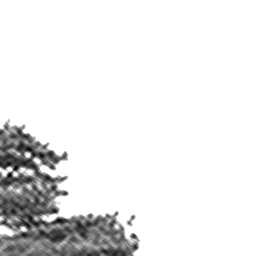

In [ ]:
residual_freq = diff_spectrum.copy() * 1

residual_freq[64:, 64:] = 0

residual_freq_exp = np.exp(residual_freq)

# apply multiplicative modifier to the Reference DCT coefficients and inverse DCT to reconstruct a spatial image
ref_coeffs = coefficients[names[0]].copy()

# match shapes (diff_spectrum_exp may be padded to the larger shape)
if residual_freq_exp.shape != ref_coeffs.shape:
    diff_mod = residual_freq_exp[: ref_coeffs.shape[0], : ref_coeffs.shape[1]]
else:
    diff_mod = residual_freq_exp

adjusted_coeffs = ref_coeffs * diff_mod

# inverse DCT (type=3 is inverse of type=2 when using norm='ortho')
reconstructed = dctn(adjusted_coeffs, type=3, norm="ortho")

# clip to [0,1], convert to uint8 and display
recon_img = np.clip(reconstructed, 0.0, 1.0)
display(Image.fromarray((recon_img * 255).astype(np.uint8)))


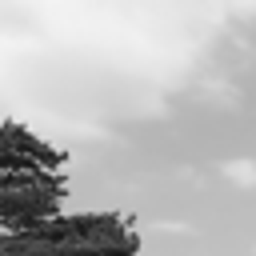

In [ ]:
display(Image.fromarray((images['Low Quality'] * 255).astype(np.uint8)).resize((256, 256)))

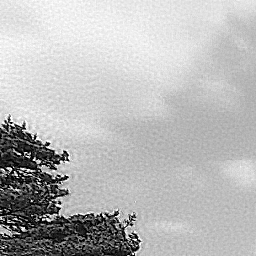

In [ ]:
residual_freq = diff_spectrum.copy() * -1

residual_freq[:64, :64] = 0

residual_freq_exp = np.exp(residual_freq)

# apply multiplicative modifier to the Reference DCT coefficients and inverse DCT to reconstruct a spatial image
ref_coeffs = coefficients[names[0]].copy()

# match shapes (diff_spectrum_exp may be padded to the larger shape)
if residual_freq_exp.shape != ref_coeffs.shape:
    diff_mod = residual_freq_exp[: ref_coeffs.shape[0], : ref_coeffs.shape[1]]
else:
    diff_mod = residual_freq_exp

adjusted_coeffs = ref_coeffs * diff_mod

# inverse DCT (type=3 is inverse of type=2 when using norm='ortho')
reconstructed = dctn(adjusted_coeffs, type=3, norm="ortho")

# clip to [0,1], convert to uint8 and display
recon_img = np.clip(reconstructed, 0.0, 1.0)
display(Image.fromarray((recon_img * 255).astype(np.uint8)))


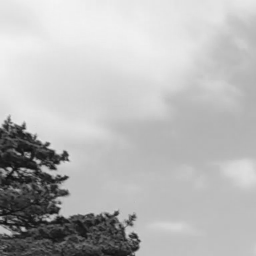

In [ ]:
display(Image.fromarray((images['Reference'] * 255).astype(np.uint8)))